# 2026-06-01 Class 1 Code

In [1]:
import numpy as np 
import matplotlib.pyplot as plt
import pandas as pd
import scipy
import PIL
import requests

In [26]:

np.random.seed(123)
x = np.arange(50)
Y = np.random.randint(0, 100, 50)

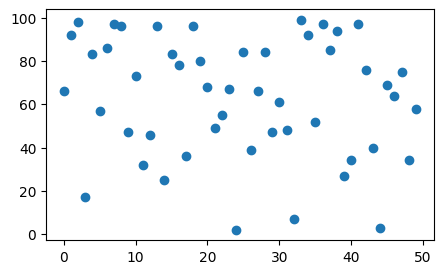

In [30]:
fig, ax = plt.subplots(figsize=(5, 3))
ax.scatter(x, Y)

<BarContainer object of 50 artists>

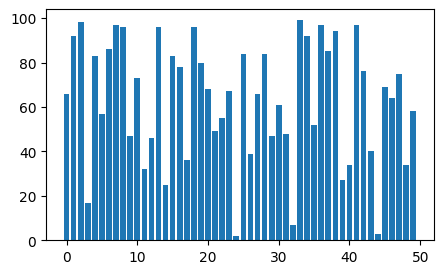

In [31]:
fig, ax = plt.subplots(figsize=(5, 3))
ax.bar(x, Y)


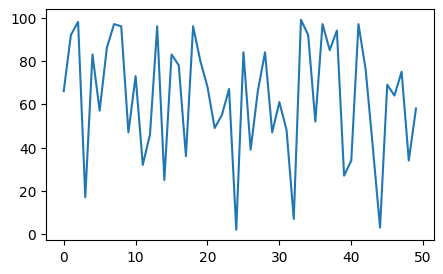

In [32]:
fig, ax = plt.subplots(figsize=(5, 3))
ax.plot(x, Y)


(array([ 3.,  1.,  2.,  6.,  5.,  4.,  7.,  4.,  7., 11.]),
 array([ 2. , 11.7, 21.4, 31.1, 40.8, 50.5, 60.2, 69.9, 79.6, 89.3, 99. ]),
 <BarContainer object of 10 artists>)

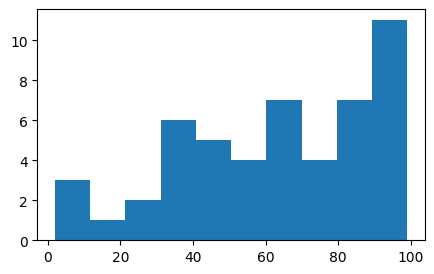

In [36]:
fig, ax = plt.subplots(figsize=(5, 3))
ax.hist(Y)


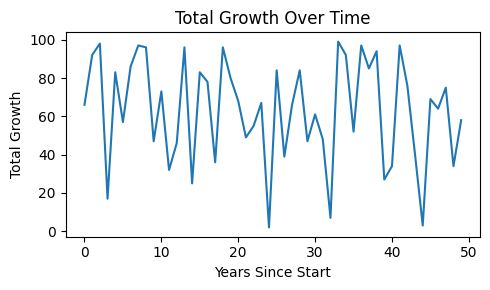

In [ ]:
fig, ax = plt.subplots(figsize=(5, 3))
ax.plot(x, Y)

ax.set_title("Total Growth Over Time")
ax.set_ylabel("Total Growth")
ax.set_xlabel("Years Since Start")
fig.tight_layout()  # adjust the width and height of the figure to look prettier



In [40]:
font1 = {'family': 'sans-serif', 'color':  'blue', 'size': 20}
font2 = {'family': 'monospace', 'color':  'green', 'size': 14}

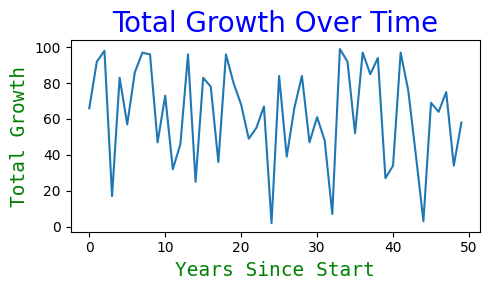

In [43]:
fig, ax = plt.subplots(figsize=(5, 3))
ax.plot(x, Y)
ax.set_title("Total Growth Over Time", fontdict=font1, loc='center')
ax.set_ylabel("Total Growth", fontdict=font2)
ax.set_xlabel("Years Since Start", fontdict=font2)
fig.tight_layout() 

C:\Users\fermi\AppData\Local\Temp\ipykernel_14128\4251905679.py:5: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show() # we don't need it here because the jupyter already shows the plot. but python (.py file) may need this to show the plot.


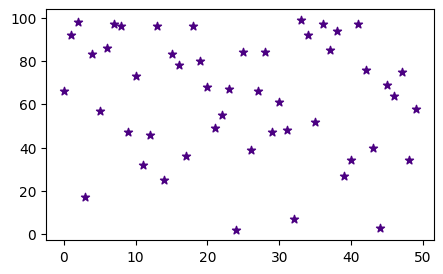

In [49]:
fig, ax = plt.subplots(figsize=(5, 3))
ax.scatter(x, Y, 
           marker='*',
           color='indigo')
fig.show() # we don't need it here because the jupyter already shows the plot. but python (.py file) may need this to show the plot.

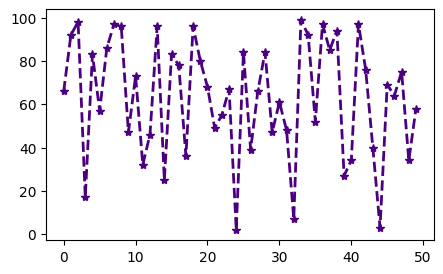

In [50]:
fig, ax = plt.subplots(figsize=(5, 3))
ax.plot(x, Y, 
        marker='*',
        color='indigo',
        linestyle='--',
        linewidth=2)

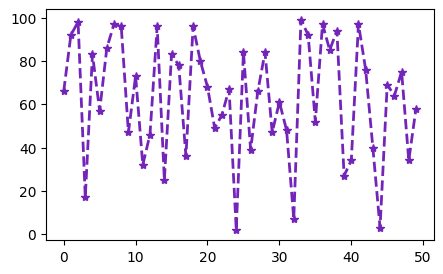

In [51]:
fig, ax = plt.subplots(figsize=(5, 3))
ax.plot(x, Y,
        marker='*',
        color='#7425b9',
        linestyle='--',
        linewidth=2,
    )

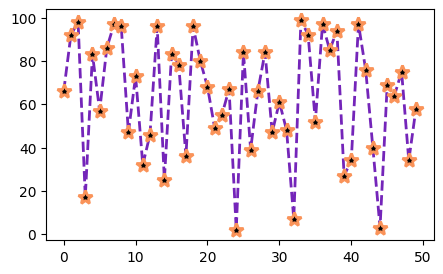

In [55]:
fig, ax = plt.subplots(figsize=(5, 3))
ax.plot(x, Y,
        marker='*',
        markersize=10,
        color='#7425b9',
        linestyle='--',
        linewidth=2,
        markeredgecolor='#fa9359',
        markerfacecolor='#000000',
        markeredgewidth=2
    )

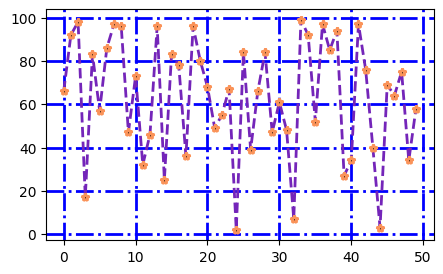

In [57]:
fig, ax = plt.subplots(figsize=(5, 3))
ax.plot(x, Y, marker='*', 
        color='#7425b9', 
        linestyle='--', 
        linewidth=2, 
        markeredgecolor='#fa9359',
        markerfacecolor='#000000',
        markeredgewidth=2)
ax.grid(axis='y', color='blue', linewidth=2, linestyle='-.')
ax.grid(axis='x', color='blue', linewidth=2, linestyle='-.')

# 2026-06-03 Class 2 Code

In [6]:
import matplotlib as mpl
import matplotlib.pyplot as plt # plotting the chart
from matplotlib.cm import ScalarMappable # creating scalar mappable objects for color mapping
from matplotlib.lines import Line2D # creating custom lines
import matplotlib.patches as mpatches # customize graphical shapes and patches
from matplotlib.patches import Patch
from textwrap import wrap # countries name lisibility

import numpy as np # arrays and mathematical functions
import pandas as pd # data manipulation
from mpl_toolkits.axes_grid1.inset_locator import inset_axes # adding inset axes within a larger plot

In [12]:
df = pd.read_csv('https://raw.githubusercontent.com/holtzy/The-Python-Graph-Gallery/master/static/data/polar_data.csv')   

# Set default font to Bell MT, Bell is the prettiest serif IMO
plt.rcParams.update({"font.family": "Arial"}) # IGNORE, Bell MT is not available in matplotlib, so I used Arial instead

# Set default font color to GREY12
plt.rcParams["text.color"] = "#1f1f1f"

# The minus glyph is not available in Bell MT
# This disables it, and uses a hyphen
plt.rc("axes", unicode_minus=False)

# Colors
COLORS = ['#914F76','#A2B9B6','tan','#4D6A67','#F9A03F','#5B2E48','#2B3B39']
cmap = mpl.colors.LinearSegmentedColormap.from_list("my color", COLORS, N=7)

# Normalizer
NUMBERS = df['Cont_code'].values
norm = mpl.colors.Normalize(vmin= NUMBERS.min(), vmax= NUMBERS.max())
COLORS = cmap(norm(NUMBERS))


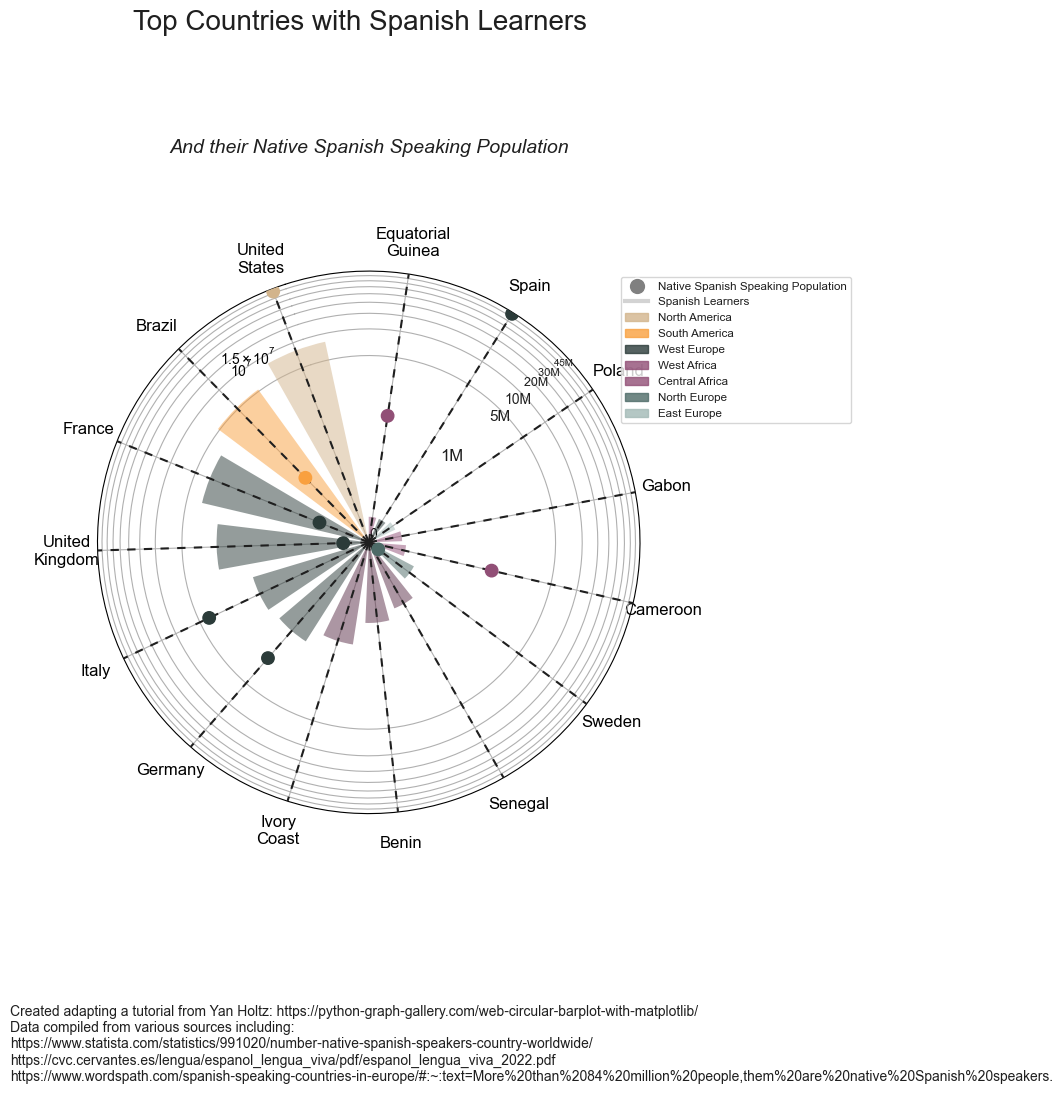

In [13]:
# Initialize layout in polar coordinates
fig, ax = plt.subplots(figsize=(7, 12.6), subplot_kw={"projection": "polar"})

# Set background color to white, both axis and figure.
fig.patch.set_facecolor("white")
ax.set_facecolor("white")

ax.set_theta_offset(1.2 * np.pi / 2)
ax.set_ylim(0, 45000000)
ax.set_yscale('symlog', linthresh=500000)

# Add bars
ANGLES = np.linspace(0.05, 2*np.pi - 0.05, len(df), endpoint = False)
LENGTHS = df['Students'].values
ax.bar(ANGLES, LENGTHS,
       color=COLORS, alpha=0.5,
       width=0.3, zorder=11,
       label='Spanish Learners')

# Add dashed vertical lines. These are just references
ax.vlines(ANGLES, 0, 45000000, color="#1f1f1f", ls=(0, (4, 4)), zorder=11)

# Add dots to represent the mean gain
MEAN_GAIN = df['Natives'].values
ax.scatter(ANGLES, MEAN_GAIN, s=80, color= COLORS, zorder=11, label = 'Native Spanish Speakers')

# Add labels for the regions
REGION = ["\n".join(wrap(r, 5, break_long_words=False)) for r in df['Country'].values]

# Set the labels
ax.set_xticks(ANGLES)
ax.set_xticklabels(REGION, size=12)
ax.set_yticks(np.arange(0,45000000,
                        step=5000000))

# Add title and subtile at the top of the chart
plt.suptitle('Top Countries with Spanish Learners',
             size = 20, y = 0.95)
plt.title('And their Native Spanish Speaking Population',
          style = 'italic', size = 14, pad = 85)

# Add scale starting at 1M and ending at 45M
PAD = 10
ax.text(-0.75 * np.pi / 2, 1000000 + PAD, "1M", ha="right", size=12)
ax.text(-0.75 * np.pi / 2, 5000000 + PAD, "5M", ha="right", size=11)
ax.text(-0.75 * np.pi / 2, 10000000 + PAD, "10M", ha="right", size=10)
ax.text(-0.75 * np.pi / 2, 20000000 + PAD, "20M ", ha="right", size=9)
ax.text(-0.75 * np.pi / 2, 30000000 + PAD, "30M ", ha="right", size=8)
ax.text(-0.75 * np.pi / 2, 46000000 + PAD, "45M ", ha="right", size=7)
XTICKS = ax.xaxis.get_major_ticks()
for tick in XTICKS:
    tick.set_pad(12)

# Add credit and sources
caption = "\n".join(["Created adapting a tutorial from Yan Holtz: https://python-graph-gallery.com/web-circular-barplot-with-matplotlib/",
                     "Data compiled from various sources including:",
                     "https://www.statista.com/statistics/991020/number-native-spanish-speakers-country-worldwide/",
                     "https://cvc.cervantes.es/lengua/espanol_lengua_viva/pdf/espanol_lengua_viva_2022.pdf",
                     "https://www.wordspath.com/spanish-speaking-countries-in-europe/#:~:text=More%20than%2084%20million%20people,them%20are%20native%20Spanish%20speakers."
])
fig.text(0, 0.1, caption, fontsize=10, ha="left", va="baseline")

# First, make some room for the legend and the caption in the bottom.
fig.subplots_adjust(bottom=0.175)

# Add customed legend
legend_elements = [Line2D([0], [0], marker='o', color='w', label='Native Spanish Speaking Population',
                          markerfacecolor='gray', markersize=12),
                          Line2D([0],[0] ,color = 'lightgray', lw = 3, label = 'Spanish Learners'),
                          mpatches.Patch(color='tan', label='North America', alpha = 0.8),
                          mpatches.Patch(color='#F9A03F', label='South America', alpha = 0.8),
                          mpatches.Patch(color='#2B3B39', label='West Europe', alpha = 0.8),
                          mpatches.Patch(color='#914F76', label='West Africa', alpha = 0.8),
                          mpatches.Patch(color='#914F76', label='Central Africa', alpha = 0.8),
                          mpatches.Patch(color='#4D6A67', label='North Europe', alpha = 0.8),
                          mpatches.Patch(color='#A2B9B6', label='East Europe', alpha = 0.8)]
ax.legend(handles=legend_elements,
          loc='upper right', # location
          bbox_to_anchor=(1.4, 1), # shift the legend
          fontsize = 'small')

# Display the final chart
plt.show()

2026-06-08 Class 3

In [17]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import scipy
import PIL
import requests

In [18]:
np.random.seed(123)
x = np.arange(50)
y1 = np.random.randint(0, 100, 50)
y2 = np.random.randint(0, 100, 50)

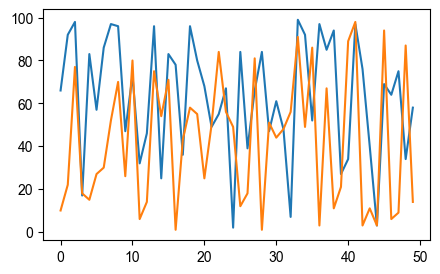

In [ ]:
fig, ax = plt.subplots(figsize=(5, 3))
ax.plot(x, y1)
ax.plot(x, y2)
# fig.show() no need for this since we are usig jupitor



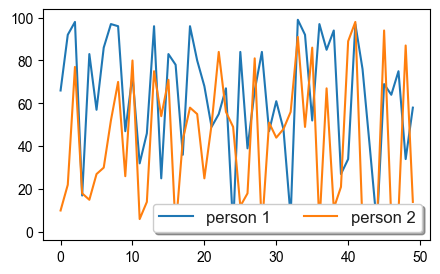

In [ ]:
# adding legend
fig, ax = plt.subplots(figsize=(5, 3))
ax.plot(x, y1, label='person 1')
ax.plot(x, y2, label='person 2')
ax.legend(loc='lower right',
          frameon=True, # add frame around the legend
          fontsize=12, # set the font size
          ncol=2, # number of columns of the legend
          shadow=True) # add shadow to the legend

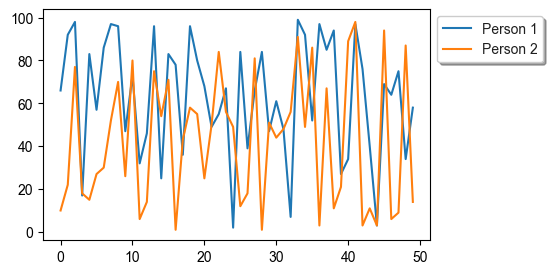

In [44]:
# moving the legend outside the plot area
fig, ax = plt.subplots(figsize=(5, 3))
ax.plot(x, y1, label='Person 1')
ax.plot(x, y2, label='Person 2')
ax.legend(loc='upper left', 
          bbox_to_anchor=(1, 1),
          ncol=1,
          shadow=True) # shift the legend

Text(10, 95, 'This value is important!')

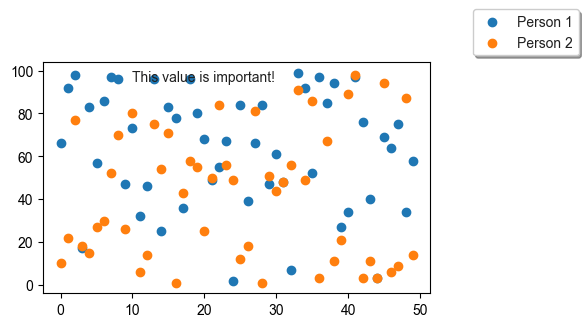

In [48]:
fig, ax=plt.subplots(figsize=(5, 3))
ax.scatter(x, y1, label='Person 1')
ax.scatter(x, y2, label='Person 2')
ax.legend(loc='lower right',
          bbox_to_anchor=(1.4, 1),
          ncol=1,
          shadow=True) # shift the legend
ax.text(10, 95, "This value is important!")

Text(10, 95, 'This is important!')

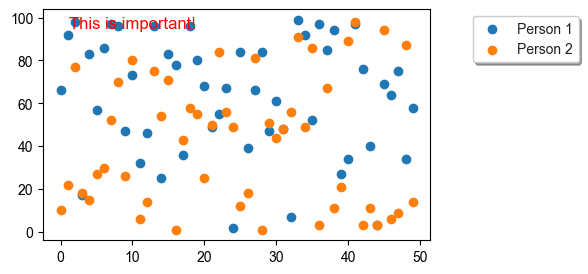

In [50]:
fig, ax=plt.subplots(figsize=(5, 3))
ax.scatter(x, y1, label ='Person 1')
ax.scatter(x, y2, label='Person 2')
ax.legend(loc='upper right', bbox_to_anchor=(1.4, 1), ncol=1, shadow=True)
ax.text(10, 95, "This is important!",
        ha='center', # horizontal alignment
        color='red',
        fontsize=12)


Text(0.2, 0.2, '. Figure:(0.2, 0.2)')

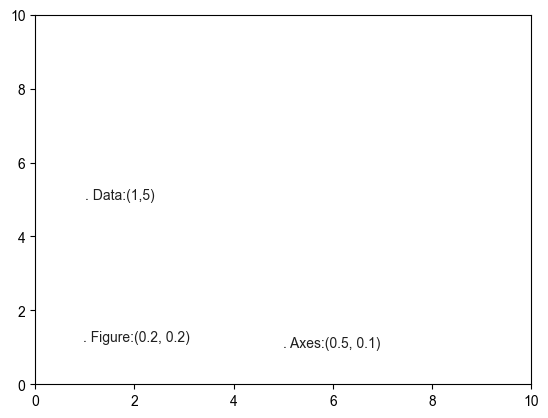

In [55]:
fig, ax=plt.subplots()
ax.axis([0, 10, 0, 10])
ax.text(1, 5, ". Data:(1,5)", transform=ax.transData) #. Data:(1,5) is just there to say which coordinates we chosen
ax.text(0.5, 0.1, ". Axes:(0.5, 0.1)", transform=ax.transAxes) #. Axes:(0.5, 0.1) is just there to say which coordinates we chosen
ax.text(0.2, 0.2, ". Figure:(0.2, 0.2)", transform=fig.transFigure) #. Figure:(0.2, 0.2) is just there to say which coordinates we chosen

Text(20, 94, 'This is important!')

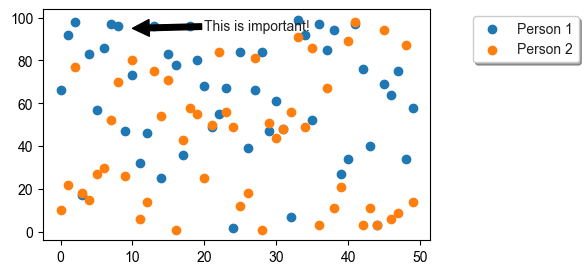

In [ ]:
fig, ax=plt.subplots(figsize=(5, 3))
ax.scatter(x, y1, label='Person 1')
ax.scatter(x, y2, label='Person 2')
ax.legend(loc='upper right', bbox_to_anchor=(1.4, 1), ncol=1, shadow=True)

# point to a specific point on the grapg with an arrow
ax.annotate('This is important!', xy=(10, 95), # location where the arrow points at
             xytext=(20, 94), # the length of the arrow
            arrowprops=dict(facecolor='black')) # color of the arrow
        


Text(20, 94, 'This is important!')

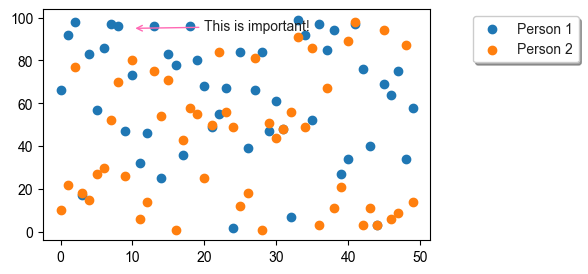

In [65]:
fig, ax=plt.subplots(figsize=(5, 3))
ax.scatter(x, y1, label='Person 1')
ax.scatter(x, y2, label='Person 2')
ax.legend(loc='upper right', bbox_to_anchor=(1.4, 1), ncol=1, shadow=True)
ax.annotate('This is important!', xy=(10, 95), xytext=(20, 94),
            arrowprops=dict(arrowstyle='->', color='hotpink'))

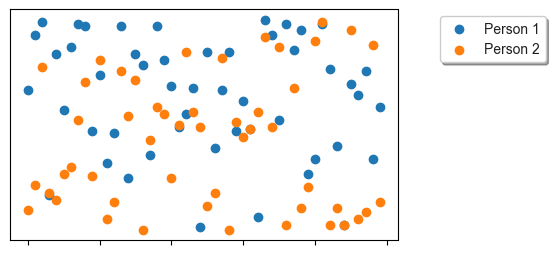

In [69]:
fig, ax=plt.subplots(figsize=(5, 3))
ax.scatter(x, y1, label='Person 1')
ax.scatter(x, y2, label='Person 2')
ax.legend(loc='upper right', bbox_to_anchor=(1.4, 1), ncol=1, shadow=True)
ax.yaxis.set_major_locator(plt.NullLocator()) #remove y-axis ticks
ax.xaxis.set_major_formatter(plt.NullFormatter()) # remove x-axis labels

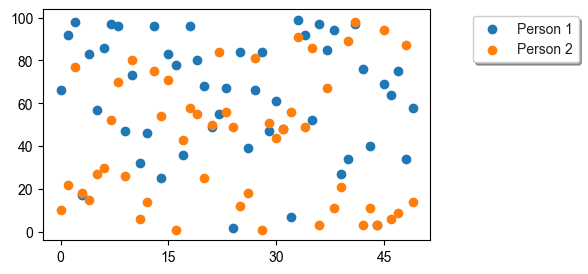

In [73]:
fig, ax= plt.subplots(figsize=(5, 3))
ax.scatter(x, y1, label='Person 1')
ax.scatter(x, y2, label='Person 2')
ax.legend(loc='upper right', bbox_to_anchor=(1.4, 1), ncol=1, shadow=True)
ax.xaxis.set_major_locator(plt.MaxNLocator(5)) # set the number of x-axis ticks to 5

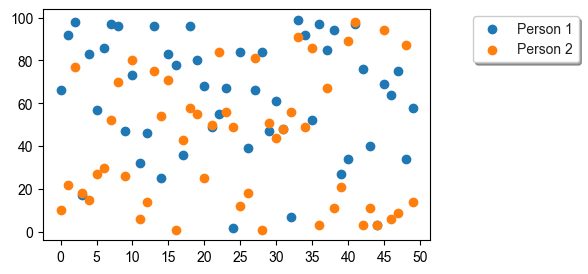

In [ ]:
fig, ax = plt.subplots(figsize=(5, 3))
ax.scatter(x, y1, label='Person 1')
ax.scatter(x, y2, label='Person 2')
ax.legend(loc='upper right', bbox_to_anchor=(1.4, 1), ncol=1, shadow=True)
ax.xaxis.set_major_locator(plt.MultipleLocator(5)) # set x-axis ticks at 5 increments

(array([-10.,   0.,  10.,  20.,  30.,  40.,  50.,  60.]),
 [Text(-10.0, 0, '-10'),
  Text(0.0, 0, '0'),
  Text(10.0, 0, '10'),
  Text(20.0, 0, '20'),
  Text(30.0, 0, '30'),
  Text(40.0, 0, '40'),
  Text(50.0, 0, '50'),
  Text(60.0, 0, '60')])

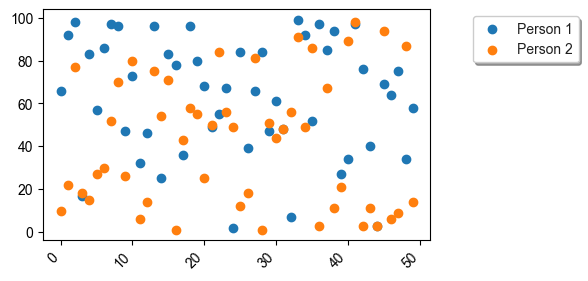

In [75]:
fig, ax = plt.subplots(figsize=(5, 3))
ax.scatter(x, y1, label='Person 1')
ax.scatter(x, y2, label='Person 2')
ax.legend(loc='upper right', bbox_to_anchor=(1.4, 1), ncol=1, shadow=True)

plt.xticks(rotation=45, ha='right') # rotate x-axis labels by 45 degrees and align them to the right

Text(0.5, 0, 'Shiny New X Axis')

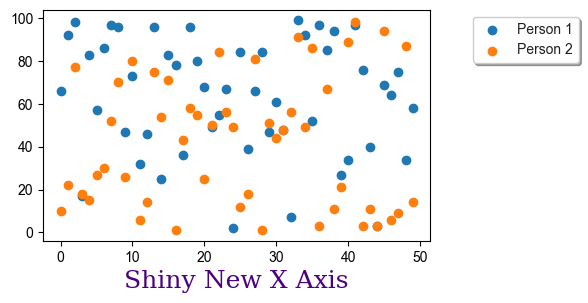

In [ ]:
# Activity
font1 = {'family': 'serif', 'color':  'indigo'} #defining the label font features
fig, ax = plt.subplots(figsize=(5, 3))
ax.scatter(x, y1, label='Person 1')
ax.scatter(x, y2, label='Person 2')
ax.legend(loc='upper right', bbox_to_anchor=(1.4, 1), ncol=1, shadow=True)

plt.xlabel('Shiny New X Axis', fontsize=18, fontdict=font1) # set x-axis label with the defined font features

In [ ]:
plt.style.available # check available styles


['Solarize_Light2',
 '_classic_test_patch',
 '_mpl-gallery',
 '_mpl-gallery-nogrid',
 'bmh',
 'classic',
 'dark_background',
 'fast',
 'fivethirtyeight',
 'ggplot',
 'grayscale',
 'petroff10',
 'seaborn-v0_8',
 'seaborn-v0_8-bright',
 'seaborn-v0_8-colorblind',
 'seaborn-v0_8-dark',
 'seaborn-v0_8-dark-palette',
 'seaborn-v0_8-darkgrid',
 'seaborn-v0_8-deep',
 'seaborn-v0_8-muted',
 'seaborn-v0_8-notebook',
 'seaborn-v0_8-paper',
 'seaborn-v0_8-pastel',
 'seaborn-v0_8-poster',
 'seaborn-v0_8-talk',
 'seaborn-v0_8-ticks',
 'seaborn-v0_8-white',
 'seaborn-v0_8-whitegrid',
 'tableau-colorblind10']

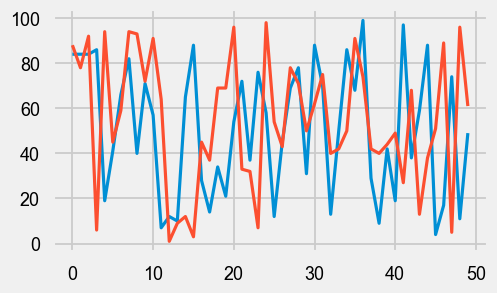

In [ ]:
plt.style.use('seaborn-v0_8-talk') # style of the plot label chosen from the styles above

np.random.seed(111)
x = np.arange(50) # create an array of 50 numbers from 0 to 49
y1 = np.random.randint(0, 100, 50) # create an array of 50 random ints between 0 and 99 for y1
y2 = np.random.randint(0, 100, 50) # create an array of 50 random ints between 0 and 99 for y2

fig, ax = plt.subplots(figsize=(5, 3))
ax.plot(x, y1)
ax.plot(x, y2)


2026-06-10 Class 4

In [86]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import scipy
import PIL
import requests

In [88]:
np.random.seed(613)
x1 = np.arange(50)
y1 = np.random.randint(0, 75,50)
x2 = np.array(["Luffy", "Zoro", "Nami", "Usopp", "Sanji"]) # diffferent x values from the fist set; not int
y2 = np.array([110, 180, 240, 99, 220]) # defining set y values for the second set of data

<BarContainer object of 5 artists>

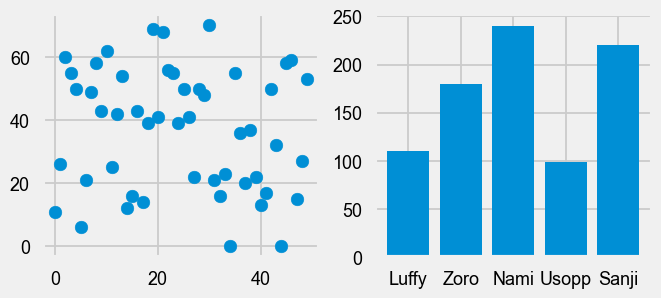

In [90]:
fig, (ax1, ax2) = plt.subplots(ncols=2, # each graph in a separate column
                               nrows=1, # both graphs in the same row
                               figsize=(7, 3))

ax1.scatter(x1, y1)
ax2.bar(x2, y2)

([0, 1, 2, 3, 4],
 [Text(0, 0, 'Luffy'),
  Text(1, 0, 'Zoro'),
  Text(2, 0, 'Nami'),
  Text(3, 0, 'Usopp'),
  Text(4, 0, 'Sanji')])

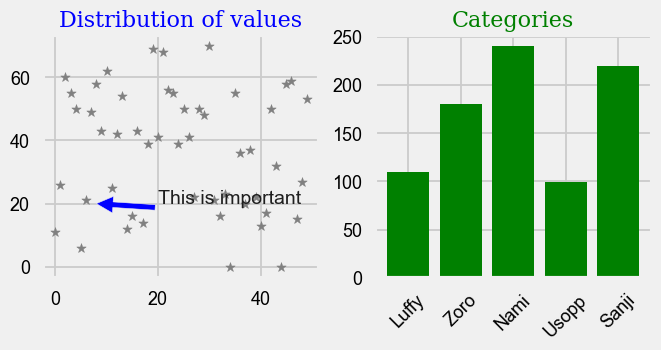

In [152]:
# Activity

fig, (ax1, ax2) = plt.subplots(ncols=2, # each graph in a separate column
                               nrows=1, # both graphs in the same row
                               figsize=(7, 3)) # set the background color of the figure to light gray

# style of the plot label chosen from the styles above
ax1.scatter(x1, y1, facecolor='grey', marker='*', s=50) # smaller marker size
ax1.set_title("Distribution of values", fontdict={'family': 'serif', 'color':  'blue', 'size': 16})
ax1.annotate('This is important', xy=(8, 20), xytext=(20, 20),
            arrowprops=dict(facecolor='blue'))


ax2.bar(x2, y2, facecolor='green')
ax2.set_title("Categories", fontdict={'family': 'serif', 'color':  'green', 'size': 16})
plt.xticks(rotation=45, ha='center') # rotate x-axis labels by 45 degrees and align them to the right


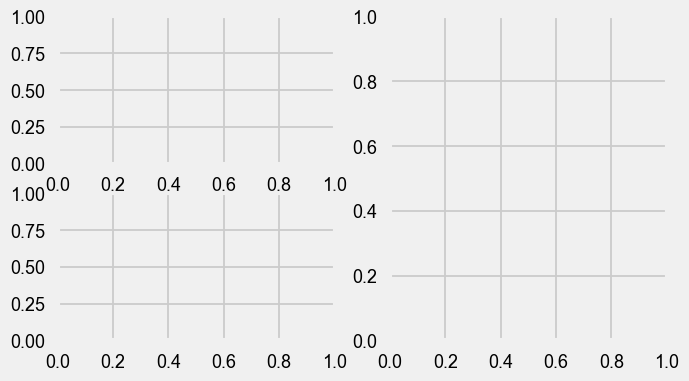

In [153]:
fig, someaxes = plt.subplot_mosaic([['ax1', 'ax3'],
                                ['ax2', 'ax3']],
                                figsize=(7, 4))

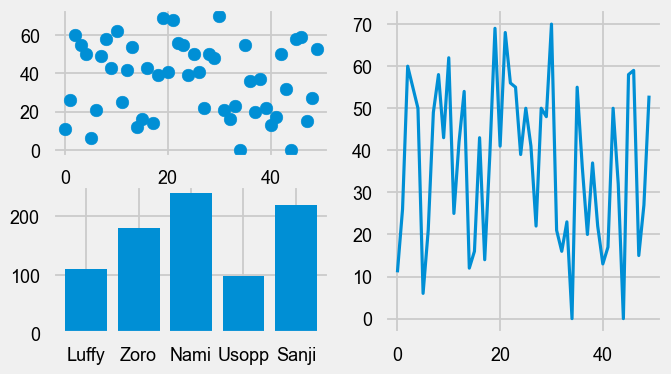

In [154]:
fig, someaxes = plt.subplot_mosaic([['ax1', 'ax3'],
                                ['ax2', 'ax3']],
                                figsize=(7, 4))
someaxes["ax1"].scatter(x1,y1)
someaxes["ax2"].bar(x2,y2)
someaxes["ax3"].plot(x1,y1)

Text(0.5, 0, 'Label 2: 2 Fast 2 Furious')

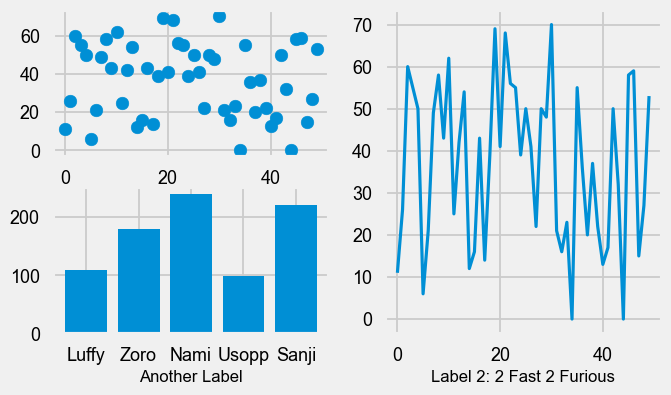

In [ ]:
fig, someaxes = plt.subplot_mosaic([['ax1', 'ax3'],
                                ['ax2', 'ax3']],
                                figsize=(7, 4)) 
someaxes["ax1"].scatter(x1,y1)
someaxes["ax2"].bar(x2,y2)
someaxes["ax3"].plot(x1,y1)
someaxes["ax1"].set_xlabel('A Big Label',fontsize=18)
someaxes["ax2"].set_xlabel('Another Label',fontsize=18)
someaxes["ax3"].set_xlabel('Label 2: 2 Fast 2 Furious',fontsize=18)

Text(0.5, 0, 'Label 2: 2 Fast 2 Furious')

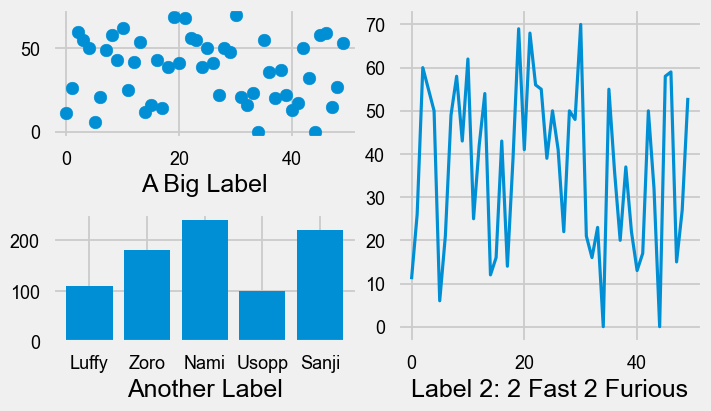

In [158]:
fig, someaxes = plt.subplot_mosaic([['ax1', 'ax3'],
                                ['ax2', 'ax3']],
                                figsize=(7, 4),
                                layout = "constrained")
someaxes["ax1"].scatter(x1,y1)
someaxes["ax2"].bar(x2,y2)
someaxes["ax3"].plot(x1,y1)
someaxes["ax1"].set_xlabel('A Big Label', fontsize=18)
someaxes["ax2"].set_xlabel('Another Label', fontsize=18)
someaxes["ax3"].set_xlabel('Label 2: 2 Fast 2 Furious', fontsize=18)

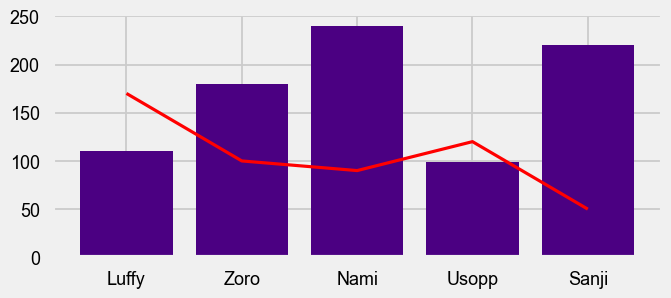

In [ ]:
# to layout multiple plots within one plot

x = np.array(["Luffy", "Zoro", "Nami", "Usopp", "Sanji"])
y1 = np.array([110, 180, 240, 99, 220])
y2 = np.array([170, 100, 90, 120, 50])

# define our figure and axes 
fig, ax = plt.subplots(figsize=(7, 3))

# first graph
ax.bar(x, y1,
color = "indigo")

# second graph
ax.plot(x, y2,
color = "red")

<ErrorbarContainer object of 3 artists>

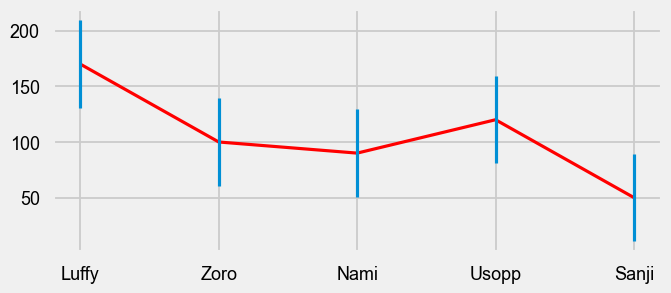

In [163]:
y2_sd = np.std(y2) #calculating STD deviation of y2

# the second figure from previous graph
fig, ax = plt.subplots(figsize=(7, 3))
ax.plot(x, y2, color = "red")

#adding error bars to the graph
ax.errorbar(x, #our x values
        y2, #our y values
        yerr = y2_sd,
        fmt = "none")

<ErrorbarContainer object of 3 artists>

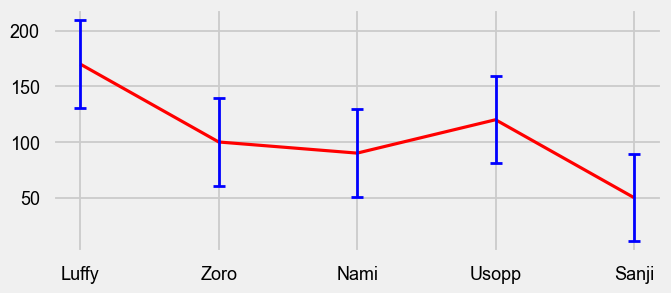

In [166]:
fig, ax = plt.subplots(figsize=(7, 3))
ax.plot(x, y2,
        color = "red")

# here we costumize the error bars with different colors, line width, and cap size
ax.errorbar(x,
        y2,
        yerr = y2_sd,
        fmt = "none",
        ecolor= "blue",
        elinewidth= 2,
        capsize = 4,
        capthick= 2 )

<ErrorbarContainer object of 3 artists>

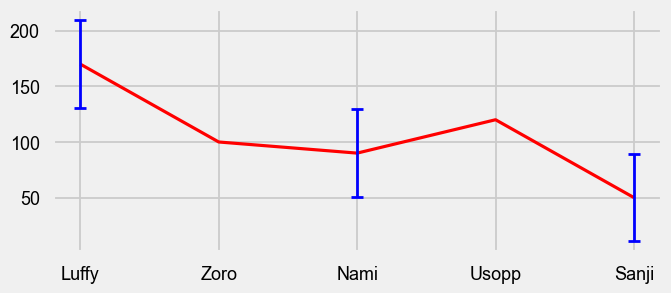

In [168]:
fig, ax = plt.subplots(figsize=(7, 3))
ax.plot(x, y2,
        color = "red")

# to have error bars in specific points
ax.errorbar(x,
        y2,
        yerr = y2_sd,
        fmt = "none",
        ecolor = "blue",
        elinewidth = 2,
        capsize = 4,
        capthick = 2,
        errorevery= 2 )

In [169]:
# adding images to graps
from PIL import Image # to open images
import requests # to get images from URLs
from io import BytesIO # to store images

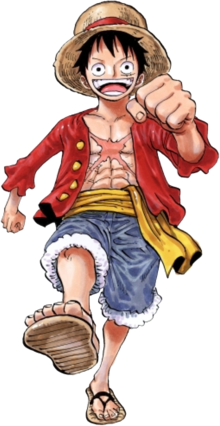

In [ ]:
# downloading an image from the web and opening it with PIL

url = "https://upload.wikimedia.org/wikipedia/en/c/cb/Monkey_D_Luffy.png"
headers = {"User-Agent": "Mozilla/5.0",
           "Accept": "image/*,*/*;q=0.8",
           "Referer": "https://en.wikipedia.org/"
}
response = requests.get(url, headers=headers)
image_file = BytesIO(response.content)
image = Image.open(image_file)
image



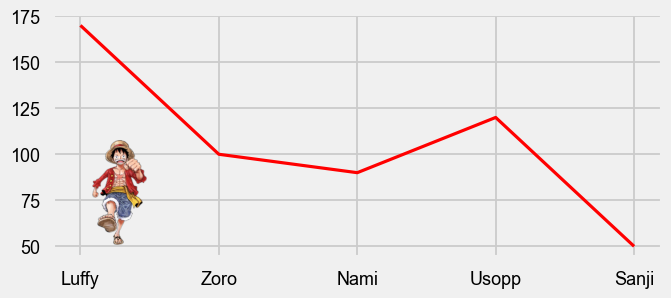

In [185]:
# our original plot
fig, ax = plt.subplots(figsize=(7, 3))
ax.plot(x, y2, color = "red")

#overlay axis from the image 
ax_image = fig.add_axes([0.1, # x coordinate 
                        0.11, # y coordinate 
                        0.15, # image width
                        0.35] # image height
                        )

# adding image to the plot
ax_image.imshow(image)
# to remove the margines of the image
ax_image.axis('off')

path = 'D:/Repositories/visualization/02_activities/assignments/participation'
filename = '/Fig1a.png'
plt.savefig(path+filename, dpi=300)


2026-06-15 Class 5

In [187]:
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import scipy
import PIL
import requests

In [188]:
tips = sns.load_dataset("tips")
print(tips)

     total_bill   tip     sex smoker   day    time  size
0         16.99  1.01  Female     No   Sun  Dinner     2
1         10.34  1.66    Male     No   Sun  Dinner     3
2         21.01  3.50    Male     No   Sun  Dinner     3
3         23.68  3.31    Male     No   Sun  Dinner     2
4         24.59  3.61  Female     No   Sun  Dinner     4
..          ...   ...     ...    ...   ...     ...   ...
239       29.03  5.92    Male     No   Sat  Dinner     3
240       27.18  2.00  Female    Yes   Sat  Dinner     2
241       22.67  2.00    Male    Yes   Sat  Dinner     2
242       17.82  1.75    Male     No   Sat  Dinner     2
243       18.78  3.00  Female     No  Thur  Dinner     2

[244 rows x 7 columns]


<Axes: xlabel='total_bill', ylabel='tip'>

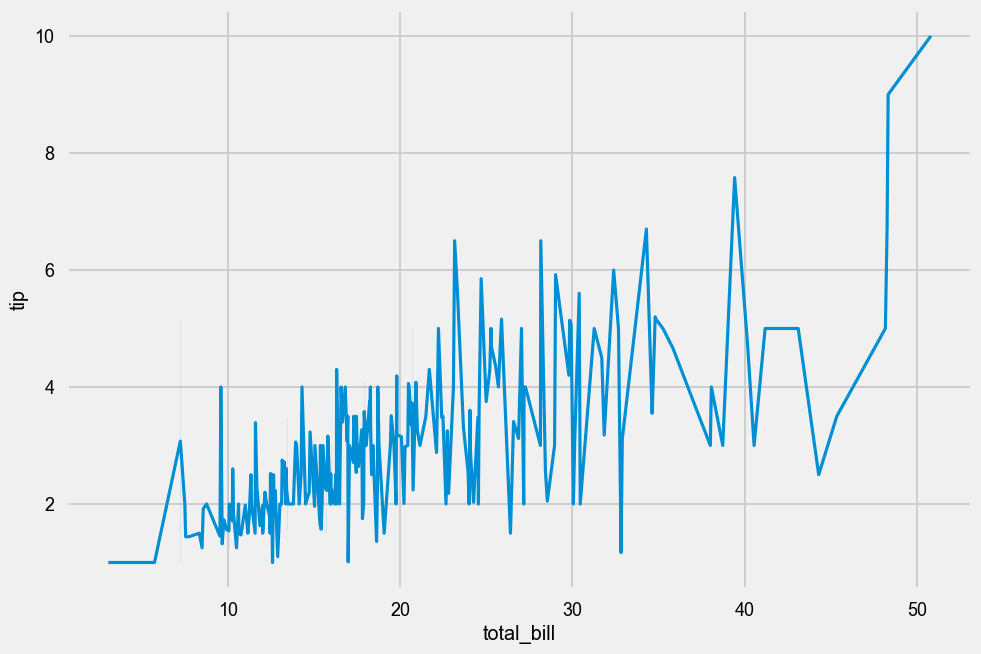

In [189]:
sns.lineplot(data=tips,       # the dataset of interest
           x='total_bill',  # x axis variable
           y='tip') # y axis

[Text(0.5, 1.0, 'Tips vs. Total Bill'),
 Text(0.5, 0, 'Total Bill ($)'),
 Text(0, 0.5, 'Tip Amount ($)')]

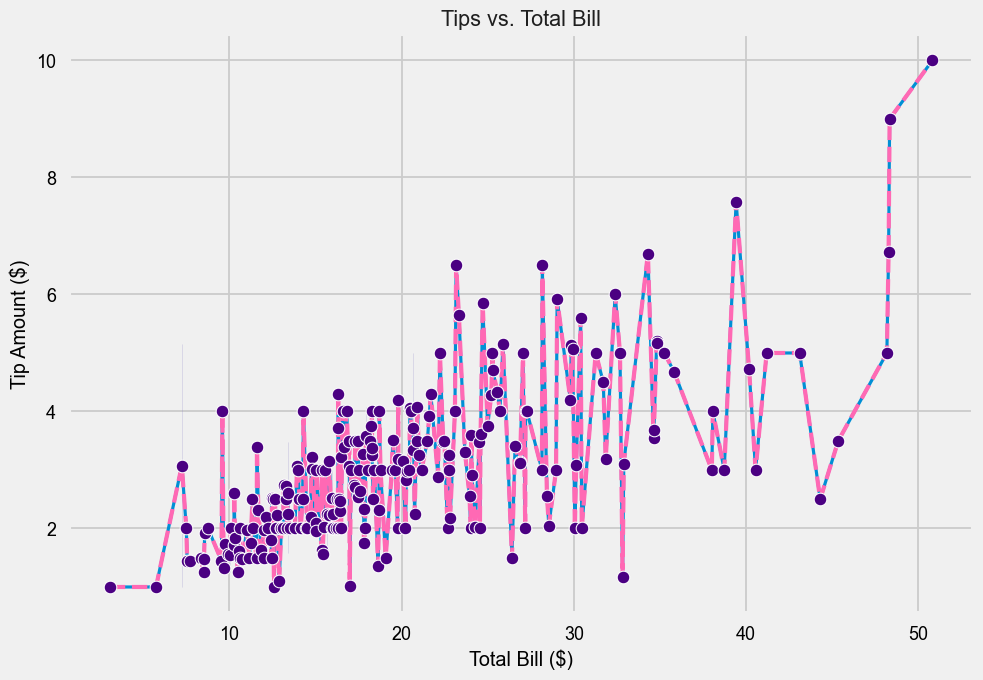

In [197]:
# customize the graph
sns.axes_style('whitegrid') 

sns.lineplot(data=tips,   
           x='total_bill',  
           y='tip') 

# first we need to pick a new name for the graph    
tipgraph = sns.lineplot(data=tips,
                        x='total_bill',
                        y='tip',
                        color='hotpink',
                        linestyle='--',
                        linewidth=3,
                        marker='o',
                        markerfacecolor='indigo')
tipgraph.set(title='Tips vs. Total Bill', 
            xlabel='Total Bill ($)', 
            ylabel='Tip Amount ($)')

[Text(0.5, 1.0, 'Tips vs. Total Bill'),
 Text(0.5, 0, 'Total Bill ($)'),
 Text(0, 0.5, 'Tip Amount ($)')]

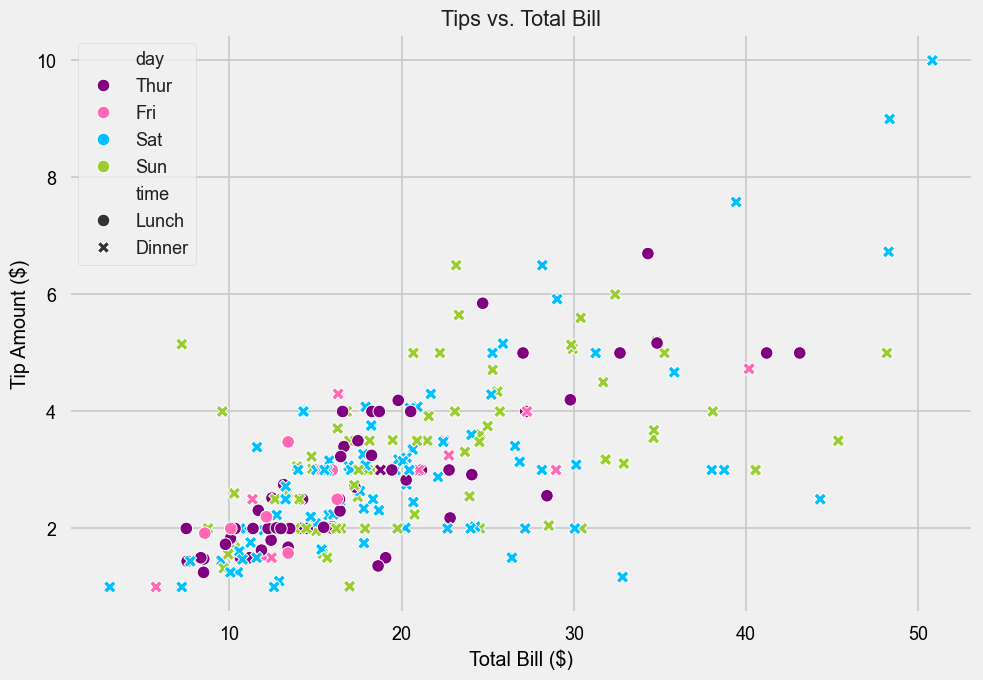

In [199]:
tipgraph = sns.scatterplot(data=tips, x='total_bill',
                        y='tip', style = 'time', hue = 
                        'day', palette = ['purple',
                        'hotpink', 'deepskyblue',
                        'yellowgreen'])
tipgraph.set(title='Tips vs. Total Bill',
            xlabel='Total Bill ($)',
            ylabel='Tip Amount ($)')

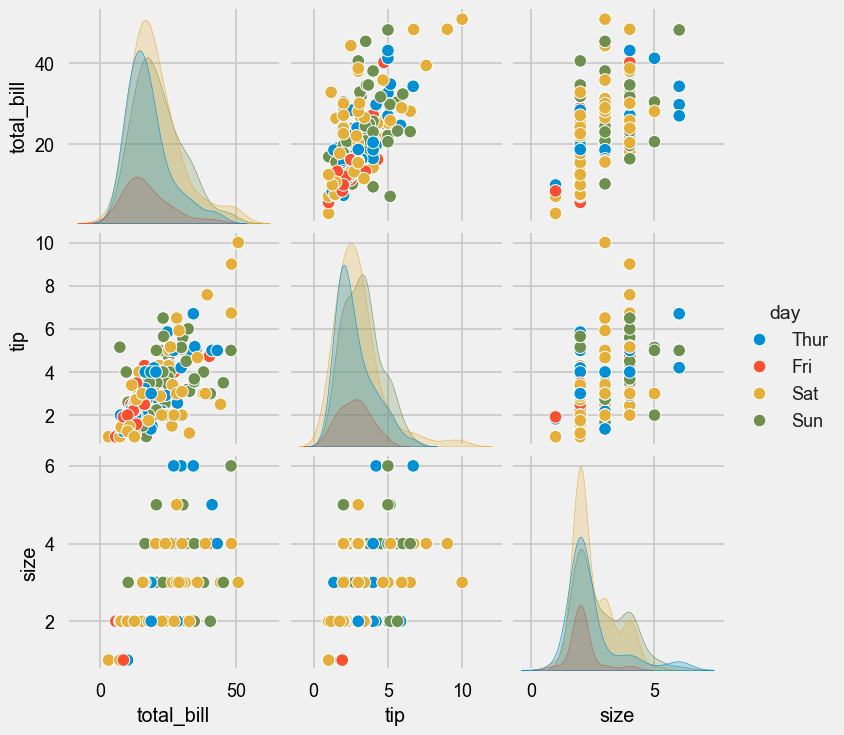

In [200]:
sns.pairplot(
      data = tips,
      hue = 'day')

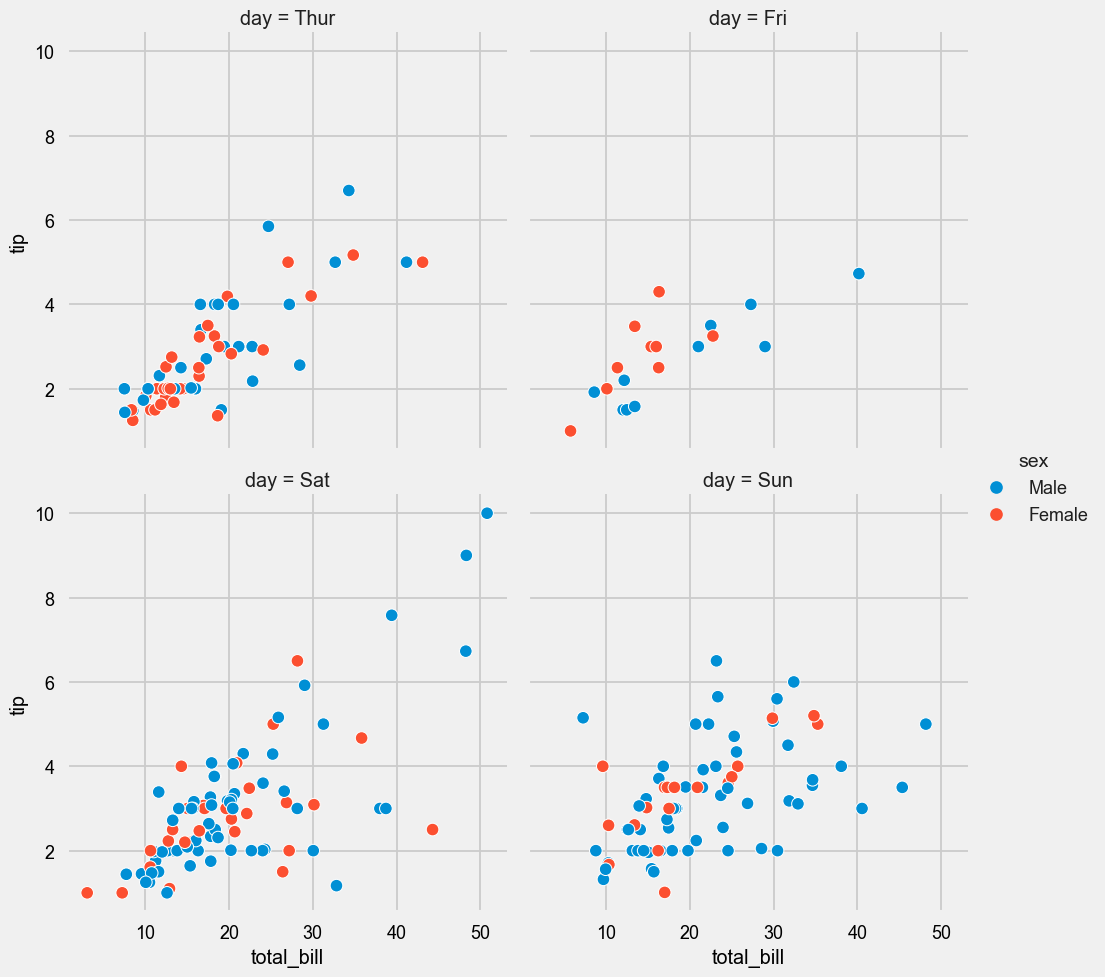

In [203]:
daysplot = sns.relplot(
            data=tips,
            x="total_bill",
            y="tip",
            hue="sex",
            col="day",
            kind="scatter",
            col_wrap=2)

In [ ]:
import plotly.graph_objects as go     # 'go' is 'graph objects’
from wordcloud import WordCloud
from matplotlib_venn import venn2,venn2_circles, venn2_unweighted

In [ ]:
x1 = np.array(["Luffy", "Zoro", "Nami", "Usopp", "Sanji"])
y1 = np.array([110, 180, 240, 99, 220])

graph = go.Figure() #creating an empty graph first
graph.add_trace(go.Bar(x=x1, y=y1)) # populating the graph

# updating the layout
graph.update_layout(
    title="Pirate Scores",
    xaxis_title="Pirates",
    yaxis_title="Score")

# saving the graph as .html for web format
#graph.write_html('D:/Repositories/visualization/02_activities/assignments/participation/pirategraph.html')

In [217]:
# customizing the graph
x1 = np.array(["Luffy", "Zoro", "Nami", "Usopp", "Sanji"])
y1 = np.array([110, 180, 240, 99, 220])

graph = go.Figure() #creating an empty graph first
graph.add_trace(go.Scatter(x=x1, y=y1, mode='markers', 
    marker=dict(
        size=15,
        color='hotpink',
        opacity=1,
        line=dict(width=5, color='purple')
    ))) 


graph.update_layout(
    title='Interactive Pirate Plot',
    xaxis_title='Pirates',
    yaxis_title='Score',
    width=500,
    height=500)

In [221]:
df = pd.read_csv('D:/Repositories/visualization/01_materials/movie_quotes.csv',
on_bad_lines='skip')
df

,quote,movie,type,year
0,"Do, or do not. There is no try.",Star Wars: Episode V - The Empire Strikes Back,movie,1890
1,Listen to them. Children of the night. What mu...,Dracula,movie,1931
2,It's alive! It's alive!,Frankenstein,movie,1931
3,"Oh, no, it wasn't the airplanes. It was Beauty...",King Kong,movie,1933
4,"Magic Mirror on the wall, who is the fairest o...",Snow White and the Seven Dwarves,movie,1937
...,...,...,...,...
727,I didn't know if you were lost. Stick with me....,Us,movie,2019
728,This guy's awesome! He's holding his own while...,Dragon Ball Super: Broly,movie,2019
729,"Murder is murder, it don’t matter who you are.",Black and Blue,movie,2019
730,You know what a lion is? A lion is a strong an...,Between Two Ferns: The Movie,movie,2019


(np.float64(-0.5), np.float64(399.5), np.float64(199.5), np.float64(-0.5))

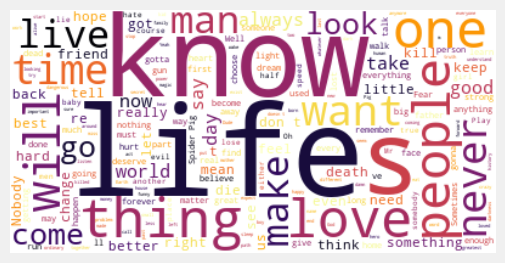

In [ ]:
# join all our text from each row from our quote column into a string
text = " ".join(each for each in df.quote) # df.quote represents the quote column
# generate our wordcloud image
wordcloud = WordCloud(background_color="white",
colormap = 'inferno').generate(text)
# use matplotlib syntax to put our image in a figure
fig, ax = plt.subplots(figsize=(7, 3))
ax.imshow(wordcloud,                  # imshow added pictures to our matplotlib axes
        interpolation='bilinear')   # this line helps smooth our image
ax.axis("off")

d:\Repositories\visualization\visualization-env\Lib\site-packages\matplotlib_venn\_util.py:32: UserWarning:

venn2_unweighted is deprecated. Use venn2 with the appropriate layout_algorithm instead.



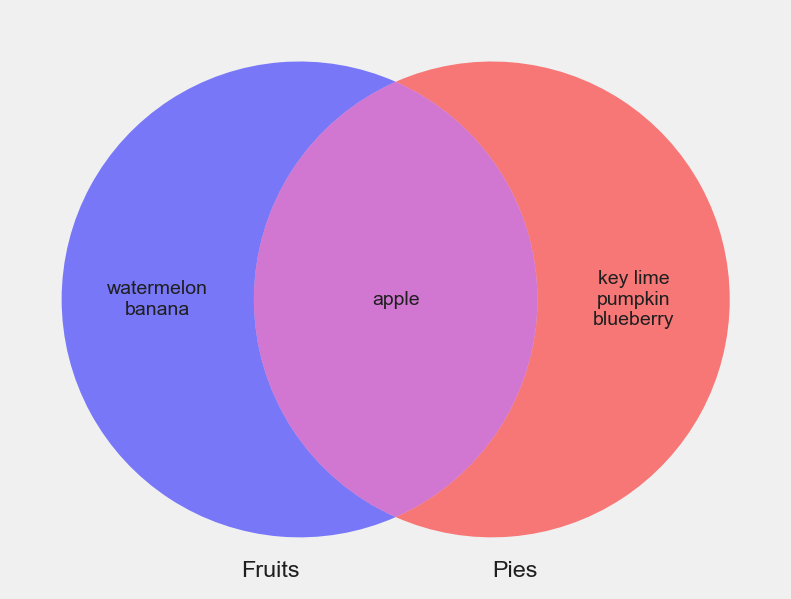

In [226]:
A = set(["apple", "banana", "watermelon"])
B = set(["pumpkin", "blueberry", "apple", "key lime"])
# creating venn diagram 
diagram = venn2_unweighted([A, B],
                            set_labels = ('Fruits', 'Pies'),
                            set_colors=("blue", "red"),
                            alpha=0.5)

# modifying the graph
diagram.get_label_by_id("10").set_text("\n".join(A - B))
diagram.get_label_by_id("11").set_text("\n".join(A & B))
diagram.get_label_by_id("01").set_text("\n".join(B - A))